In [1]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(42)

N = 50000  # synthetic samples

# Create output directory
os.makedirs('../data/synthetic', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print(f"✅ Libraries loaded")
print(f"✅ Generating {N} synthetic patient records")

✅ Libraries loaded
✅ Generating 50000 synthetic patient records


In [2]:
# Age distribution (realistic population)
age = np.random.normal(45, 15, N).clip(18, 85).astype(int)

# Height in cm (men: ~175, women: ~162)
gender = np.random.choice([0, 1], N)  # 0=female, 1=male
height = np.where(
    gender == 1,
    np.random.normal(175, 7, N),
    np.random.normal(162, 6, N)
).clip(145, 210)

# Weight in kg
weight = np.random.normal(70, 15, N).clip(40, 150)

# BMI
bmi = (weight / ((height / 100) ** 2)).round(1)

print(f"✅ Demographics generated")
print(f"   Age range: {age.min()} - {age.max()}")
print(f"   BMI range: {bmi.min():.1f} - {bmi.max():.1f}")
print(f"   Avg BMI: {bmi.mean():.1f}")

✅ Demographics generated
   Age range: 18 - 85
   BMI range: 10.4 - 58.2
   Avg BMI: 24.9


In [3]:
# Blood pressure — increases with age and BMI
bp_base_systolic = 100 + (age * 0.4) + (bmi * 0.5) + np.random.normal(0, 10, N)
bp_base_diastolic = 65 + (age * 0.2) + (bmi * 0.3) + np.random.normal(0, 7, N)

avg_systolic = bp_base_systolic.clip(85, 200).round(1)
avg_diastolic = bp_base_diastolic.clip(55, 120).round(1)

# BP variability (higher in older/heavier patients)
bp_variability = (3 + (age * 0.05) + (bmi * 0.1) + np.random.exponential(3, N)).clip(0, 30).round(1)

# Blood sugar — correlated with BMI and age
sugar_base = 75 + (bmi * 1.2) + (age * 0.3) + np.random.normal(0, 20, N)
avg_glucose = sugar_base.clip(60, 350).round(1)

# Sugar variability
sugar_variability = (5 + (avg_glucose * 0.05) + np.random.exponential(5, N)).clip(0, 60).round(1)

# Pulse rate
avg_pulse = (75 - (age * 0.1) + np.random.normal(0, 10, N)).clip(45, 130).round(1)

print(f"✅ Vitals generated")
print(f"   Avg Systolic BP: {avg_systolic.mean():.1f} mmHg")
print(f"   Avg Blood Sugar: {avg_glucose.mean():.1f} mg/dL")
print(f"   Avg Pulse: {avg_pulse.mean():.1f} bpm")

✅ Vitals generated
   Avg Systolic BP: 130.3 mmHg
   Avg Blood Sugar: 118.4 mg/dL
   Avg Pulse: 70.5 bpm


In [4]:
# Medication adherence — lower in elderly and those with more conditions
adherence_base = 0.85 - (age * 0.002) + np.random.normal(0, 0.1, N)
adherence_rate = adherence_base.clip(0.1, 1.0).round(2)

# Missed doses per week (inversely related to adherence)
missed_doses = np.round((1 - adherence_rate) * 21).astype(int).clip(0, 15)

# Chronic conditions (more likely with age and high BMI)
chronic_prob = (0.1 + (age * 0.006) + (bmi * 0.005)).clip(0, 0.9)
has_chronic_condition = np.random.binomial(1, chronic_prob)

# Number of allergies
allergies_count = np.random.choice(
    [0, 1, 2, 3, 4, 5],
    N,
    p=[0.45, 0.25, 0.15, 0.08, 0.04, 0.03]
)

# Lifestyle scores (0-10)
physical_activity_score = (8 - (age * 0.04) - (bmi * 0.05) + np.random.normal(0, 1.5, N)).clip(0, 10).round(1)
diet_quality_score = np.random.normal(5.5, 2, N).clip(0, 10).round(1)
stress_score = (3 + (age * 0.02) + np.random.normal(0, 2, N)).clip(0, 10).round(1)
sleep_score = (7 - (stress_score * 0.3) + np.random.normal(0, 1, N)).clip(0, 10).round(1)

print(f"✅ Portal-specific fields generated")
print(f"   Avg Adherence Rate: {adherence_rate.mean():.2f}")
print(f"   Avg Missed Doses/Week: {missed_doses.mean():.1f}")
print(f"   Chronic Condition Prevalence: {has_chronic_condition.mean()*100:.1f}%")

✅ Portal-specific fields generated
   Avg Adherence Rate: 0.76
   Avg Missed Doses/Week: 5.1
   Chronic Condition Prevalence: 49.8%


In [5]:
# Diabetes risk score based on clinical factors
diabetes_score = (
    (avg_glucose > 126).astype(float) * 2.5 +
    (avg_glucose > 100).astype(float) * 1.0 +
    (bmi > 30).astype(float) * 1.5 +
    (bmi > 25).astype(float) * 0.5 +
    (age > 45).astype(float) * 1.0 +
    (age > 60).astype(float) * 0.5 +
    (has_chronic_condition).astype(float) * 0.8 +
    (adherence_rate < 0.7).astype(float) * 0.5 +
    (sugar_variability > 20).astype(float) * 0.8 +
    (physical_activity_score < 3).astype(float) * 0.6 +
    (diet_quality_score < 4).astype(float) * 0.5 +
    np.random.normal(0, 0.3, N)  # random noise
)

# Convert score to risk level
diabetes_risk = np.where(
    diabetes_score >= 4.0, 'high',
    np.where(diabetes_score >= 2.0, 'medium', 'low')
)

print(f"✅ Diabetes risk labels generated")
print(f"   Low:    {(diabetes_risk == 'low').sum():,} ({(diabetes_risk == 'low').mean()*100:.1f}%)")
print(f"   Medium: {(diabetes_risk == 'medium').sum():,} ({(diabetes_risk == 'medium').mean()*100:.1f}%)")
print(f"   High:   {(diabetes_risk == 'high').sum():,} ({(diabetes_risk == 'high').mean()*100:.1f}%)")

✅ Diabetes risk labels generated
   Low:    13,495 (27.0%)
   Medium: 16,229 (32.5%)
   High:   20,276 (40.6%)


In [6]:
# Hypertension risk score based on clinical factors
hypertension_score = (
    (avg_systolic > 140).astype(float) * 2.5 +
    (avg_systolic > 130).astype(float) * 1.0 +
    (avg_diastolic > 90).astype(float) * 2.0 +
    (avg_diastolic > 80).astype(float) * 0.8 +
    (bp_variability > 15).astype(float) * 1.0 +
    (bp_variability > 10).astype(float) * 0.5 +
    (bmi > 30).astype(float) * 1.2 +
    (age > 50).astype(float) * 1.0 +
    (age > 65).astype(float) * 0.5 +
    (has_chronic_condition).astype(float) * 0.8 +
    (adherence_rate < 0.7).astype(float) * 0.6 +
    (missed_doses > 5).astype(float) * 0.5 +
    (stress_score > 7).astype(float) * 0.6 +
    (physical_activity_score < 3).astype(float) * 0.5 +
    np.random.normal(0, 0.3, N)
)

hypertension_risk = np.where(
    hypertension_score >= 4.5, 'high',
    np.where(hypertension_score >= 2.0, 'medium', 'low')
)

print(f"✅ Hypertension risk labels generated")
print(f"   Low:    {(hypertension_risk == 'low').sum():,} ({(hypertension_risk == 'low').mean()*100:.1f}%)")
print(f"   Medium: {(hypertension_risk == 'medium').sum():,} ({(hypertension_risk == 'medium').mean()*100:.1f}%)")
print(f"   High:   {(hypertension_risk == 'high').sum():,} ({(hypertension_risk == 'high').mean()*100:.1f}%)")

✅ Hypertension risk labels generated
   Low:    16,671 (33.3%)
   Medium: 17,568 (35.1%)
   High:   15,761 (31.5%)


In [7]:
# Overall health score — higher is better
health_score = (
    100
    - (avg_systolic - 110).clip(0, 90) * 0.3
    - (avg_glucose - 90).clip(0, 260) * 0.15
    - (bmi - 22).clip(0, 28) * 0.8
    - missed_doses * 1.2
    - stress_score * 0.8
    - bp_variability * 0.4
    - sugar_variability * 0.2
    + physical_activity_score * 1.5
    + diet_quality_score * 1.0
    + sleep_score * 0.8
    + adherence_rate * 10
    + np.random.normal(0, 3, N)
).clip(10, 100).round(1)

print(f"✅ Health scores generated")
print(f"   Min Score:  {health_score.min():.1f}")
print(f"   Max Score:  {health_score.max():.1f}")
print(f"   Avg Score:  {health_score.mean():.1f}")
print(f"   Score Distribution:")
print(f"   Poor (0-40):   {((health_score < 40)).sum():,} ({((health_score < 40)).mean()*100:.1f}%)")
print(f"   Fair (40-60):  {((health_score >= 40) & (health_score < 60)).sum():,} ({((health_score >= 40) & (health_score < 60)).mean()*100:.1f}%)")
print(f"   Good (60-80):  {((health_score >= 60) & (health_score < 80)).sum():,} ({((health_score >= 60) & (health_score < 80)).mean()*100:.1f}%)")
print(f"   Excellent(80+):{(health_score >= 80).sum():,} ({(health_score >= 80).mean()*100:.1f}%)")

✅ Health scores generated
   Min Score:  46.3
   Max Score:  100.0
   Avg Score:  92.6
   Score Distribution:
   Poor (0-40):   0 (0.0%)
   Fair (40-60):  85 (0.2%)
   Good (60-80):  4,463 (8.9%)
   Excellent(80+):45,452 (90.9%)


In [8]:
df = pd.DataFrame({
    # Demographics
    'age': age,
    'gender': gender,
    'height': height.round(1),
    'weight': weight.round(1),
    'bmi': bmi,

    # Vitals
    'avg_systolic': avg_systolic,
    'avg_diastolic': avg_diastolic,
    'bp_variability': bp_variability,
    'avg_glucose': avg_glucose,
    'sugar_variability': sugar_variability,
    'avg_pulse': avg_pulse,

    # Portal-specific fields
    'adherence_rate': adherence_rate,
    'missed_doses': missed_doses,
    'has_chronic_condition': has_chronic_condition,
    'allergies_count': allergies_count,

    # Lifestyle
    'physical_activity_score': physical_activity_score,
    'diet_quality_score': diet_quality_score,
    'stress_score': stress_score,
    'sleep_score': sleep_score,

    # Labels
    'diabetes_risk': diabetes_risk,
    'hypertension_risk': hypertension_risk,
    'health_score': health_score
})

print(f"✅ DataFrame created")
print(f"   Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

✅ DataFrame created
   Shape: (50000, 22)

First 3 rows:
   age  gender  height  weight   bmi  avg_systolic  avg_diastolic  bp_variability  avg_glucose  sugar_variability  avg_pulse  adherence_rate  missed_doses  has_chronic_condition  allergies_count  physical_activity_score  diet_quality_score  stress_score  sleep_score diabetes_risk hypertension_risk  health_score
0   52       1   169.6    85.5  29.7         138.9           82.4            17.0         66.1                9.5       64.6            0.93             1                      1                3                      4.0                 7.0           8.0          4.1        medium              high          92.6
1   42       0   153.0    83.1  35.5         138.8           72.8            17.2         91.6               11.4       65.8            0.79             4                      0                1                      3.2                 5.6           6.5          4.6        medium            medium          76.5
2   

In [9]:
# Check for nulls
print("Null values:", df.isnull().sum().sum())

# Check label distribution
print("\nDiabetes Risk Distribution:")
print(df['diabetes_risk'].value_counts())

print("\nHypertension Risk Distribution:")
print(df['hypertension_risk'].value_counts())

print(f"\nHealth Score Stats:")
print(df['health_score'].describe().round(2))

# Save to CSV
output_path = '../data/synthetic/synthetic_data.csv'
df.to_csv(output_path, index=False)

print(f"\n✅ Synthetic data saved to: {output_path}")
print(f"   Total rows: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")
print(f"   File size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")

Null values: 0

Diabetes Risk Distribution:
diabetes_risk
high      20276
medium    16229
low       13495
Name: count, dtype: int64

Hypertension Risk Distribution:
hypertension_risk
medium    17568
low       16671
high      15761
Name: count, dtype: int64

Health Score Stats:
count    50000.00
mean        92.64
std          8.26
min         46.30
25%         87.70
50%         95.20
75%        100.00
max        100.00
Name: health_score, dtype: float64

✅ Synthetic data saved to: ../data/synthetic/synthetic_data.csv
   Total rows: 50,000
   Total columns: 22
   File size: 4.6 MB


Matplotlib is building the font cache; this may take a moment.


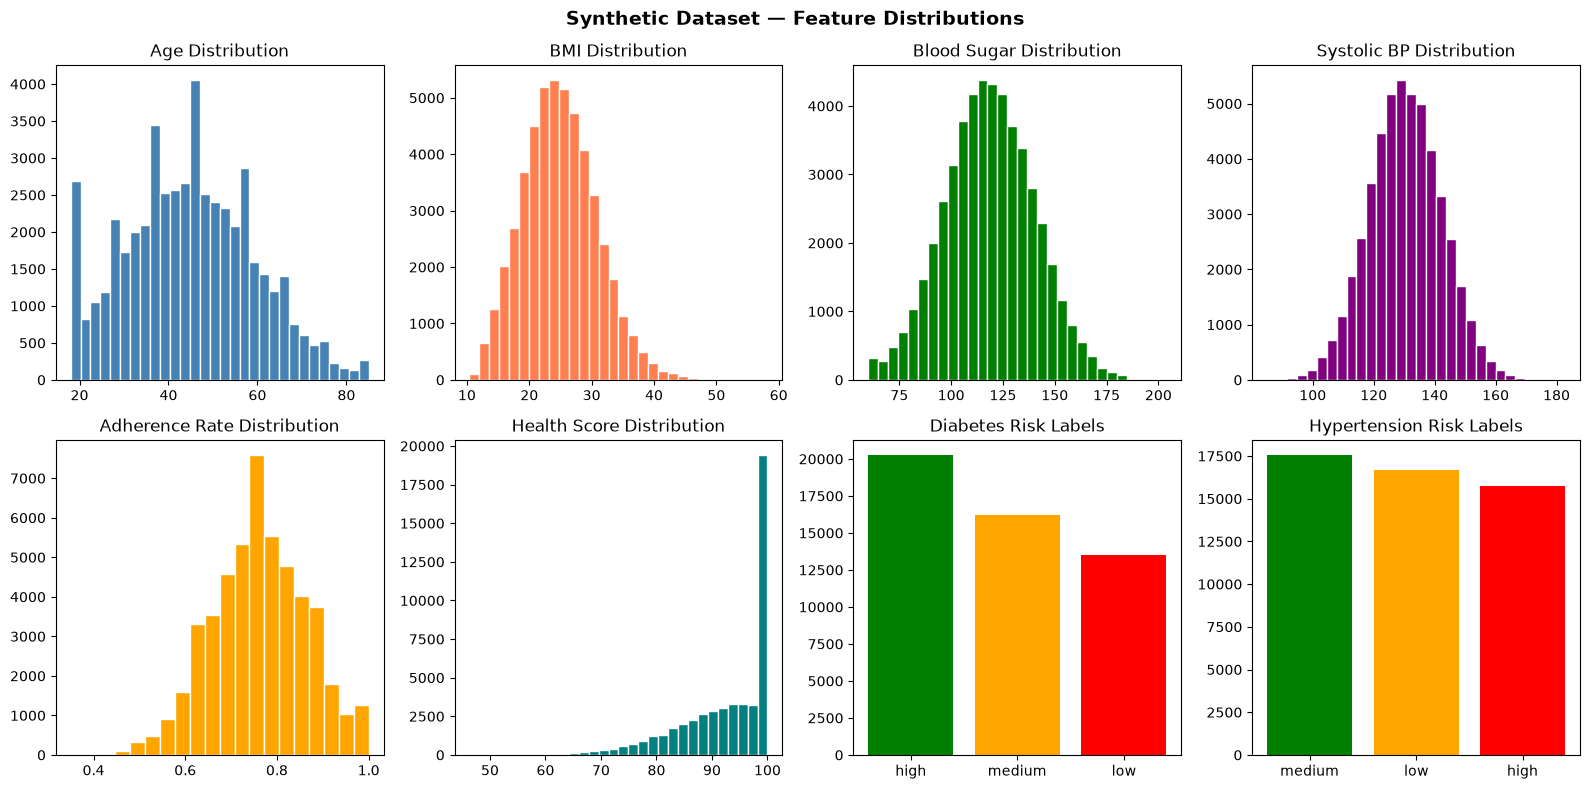

✅ Distribution plots saved!


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Synthetic Dataset — Feature Distributions', fontsize=14, fontweight='bold')

# Plot distributions
axes[0,0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')

axes[0,1].hist(df['bmi'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('BMI Distribution')

axes[0,2].hist(df['avg_glucose'], bins=30, color='green', edgecolor='white')
axes[0,2].set_title('Blood Sugar Distribution')

axes[0,3].hist(df['avg_systolic'], bins=30, color='purple', edgecolor='white')
axes[0,3].set_title('Systolic BP Distribution')

axes[1,0].hist(df['adherence_rate'], bins=20, color='orange', edgecolor='white')
axes[1,0].set_title('Adherence Rate Distribution')

axes[1,1].hist(df['health_score'], bins=30, color='teal', edgecolor='white')
axes[1,1].set_title('Health Score Distribution')

axes[1,2].bar(
    df['diabetes_risk'].value_counts().index,
    df['diabetes_risk'].value_counts().values,
    color=['green', 'orange', 'red']
)
axes[1,2].set_title('Diabetes Risk Labels')

axes[1,3].bar(
    df['hypertension_risk'].value_counts().index,
    df['hypertension_risk'].value_counts().values,
    color=['green', 'orange', 'red']
)
axes[1,3].set_title('Hypertension Risk Labels')

plt.tight_layout()
plt.savefig('../data/synthetic/distribution_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved!")